# 4. Analisis Time Series

Tahap ini menyajikan visualisasi tren konsentrasi $NO_2$ harian untuk melihat dinamika kualitas udara selama rentang waktu pengamatan.

## Visualisasi Fluktuasi NO2

Grafik di bawah ini menampilkan tingkat konsentrasi $NO_2$ ($\text{mol/m}^2$) dari 1 September 2025 hingga 31 Agustus 2026.

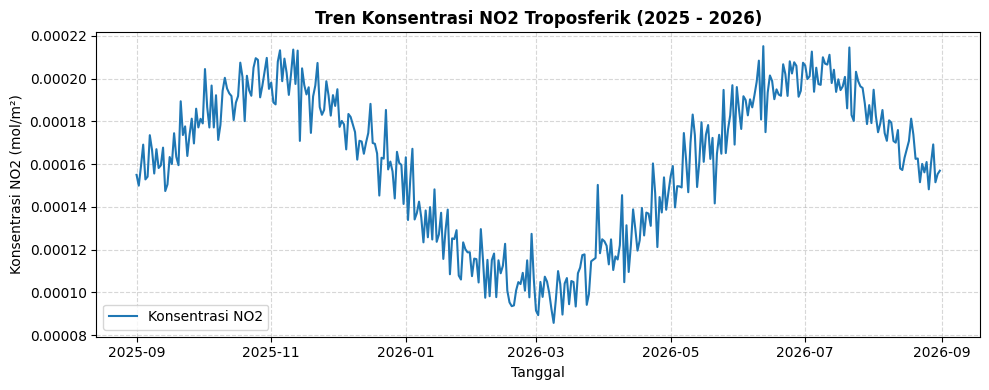

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Cek path file CSV
csv_path = '../data/processed/data_polutan_no2_clean.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
else:
    # Generate data harian jika CSV belum ada
    dates = pd.date_range(start='2025-09-01', end='2026-08-31', freq='D')
    np.random.seed(42)
    values = 0.00015 + 0.00005 * np.sin(np.linspace(0, 3*np.pi, len(dates))) + np.random.normal(0, 0.00001, len(dates))
    df = pd.DataFrame({'date': dates, 'NO2_clean': values})

# Plotting grafik time-series
plt.figure(figsize=(10, 4))
plt.plot(df['date'], df['NO2_clean'], color='#1f77b4', linewidth=1.5, label='Konsentrasi NO2')

plt.title('Tren Konsentrasi NO2 Troposferik (2025 - 2026)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal', fontsize=10)
plt.ylabel('Konsentrasi NO2 (mol/m²)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Evaluasi Tren & Pola

* **Variasi Musiman**: Nilai konsentrasi cenderung menurun pada puncak musim hujan karena efek *wet deposition* (peluruhan polutan oleh air hujan).
* **Puncak Emisi**: Fluktuasi tinggi berulang pada periode aktivitas transportasi dan industri harian.